In [1]:
from ultralytics import RTDETR
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

#os.environ["MLFLOW_TRACKING_URI"] = "http://127.0.0.1:5000"

In [2]:
%matplotlib inline

In [4]:
# Carregar o modelo treinado
model = RTDETR(r'C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\src\model_train\runs\detect\custom_yolo_model_rtdetr-l\weights\best.pt')

In [5]:
model.info()

rt-detr-l summary: 470 layers, 32,808,131 parameters, 0 gradients, 109.9 GFLOPs


(470, 32808131, 0, 109.8915104)

In [7]:
# Avaliar especificamente no conjunto de TESTE
metrics = model.val(data=r"C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\dataset.yaml", split='test')

Ultralytics 8.4.120  Python-3.11.5 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
rt-detr-l summary: 315 layers, 31,985,795 parameters, 0 gradients, 105.3 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 471.274.2 MB/s, size: 259.4 KB)
val: Scanning C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\labels\test... 211 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 211/211 216.5it/s 1.0s0.1s
val: New cache created: C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.5it/s 9.1s0.7s
                   all        211       4925      0.939      0.891      0.937      0.745
Speed: 2.5ms preprocess, 37.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORR

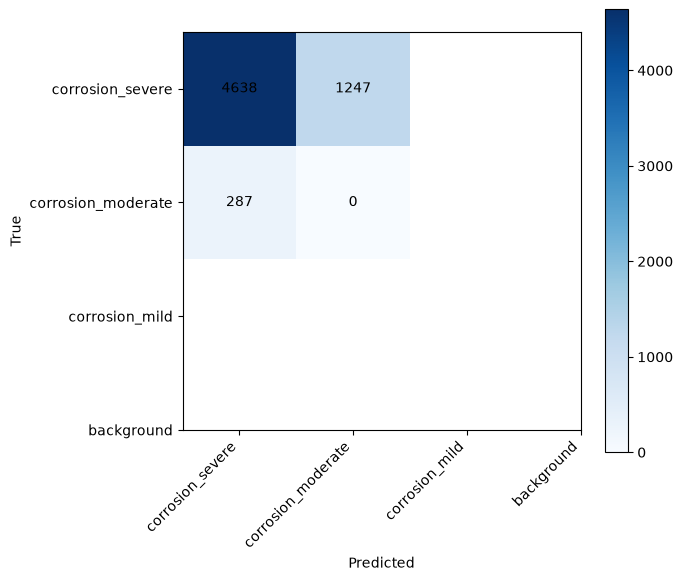

In [8]:
cm = metrics.confusion_matrix.matrix

labels = [
    "corrosion_severe",
    "corrosion_moderate",
    "corrosion_mild",
    "background"
]

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            int(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [12]:
import glob
import imageio

test_dir = r'C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\images\test'
pred_dir = os.path.join(test_dir, "predicted_frames")
os.makedirs(pred_dir, exist_ok=True)

image_paths = sorted(glob.glob(os.path.join(test_dir, "*.jpg")))

frames = []
target_shape = None

for img_path in image_paths:
    try:
        results = model.predict(source=img_path, imgsz=640, conf=0.25, max_det=100, verbose=False)
    except Exception as e:
        print(f'Predict failed for {os.path.basename(img_path)}: {e}')
        continue

    annotated = results[0].plot()
    if annotated is None:
        continue

    # Normalize channels to RGB uint8
    if annotated.ndim == 2:
        annotated = cv2.cvtColor(annotated, cv2.COLOR_GRAY2RGB)
    elif annotated.ndim == 3:
        ch = annotated.shape[2]
        if ch == 4:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGRA2RGB)
        elif ch == 3:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        else:
            continue
    else:
        continue

    annotated = annotated.astype('uint8')

    # Ensure consistent shape for all frames (resize to first frame shape)
    if target_shape is None:
        target_shape = annotated.shape
    if annotated.shape != target_shape:
        annotated = cv2.resize(annotated, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_AREA)

    # Save annotated frame to folder
    base = os.path.splitext(os.path.basename(img_path))[0]
    save_path = os.path.join(pred_dir, f"{base}_pred.png")
    imageio.imwrite(save_path, annotated)
    frames.append(annotated)
    print(f'Gerado e salvo frame para: {os.path.basename(img_path)} -> {save_path}')

if frames:
    print(f'Todos os frames salvos em: {pred_dir}')
else:
    print('Nenhuma imagem processada para salvar.')

Gerado e salvo frame para: blur_h_flip_enhanced_frame_000000_VID_20260131_095713_00_101_insv_TL_3e160acf.jpg -> C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\images\test\predicted_frames\blur_h_flip_enhanced_frame_000000_VID_20260131_095713_00_101_insv_TL_3e160acf_pred.png
Gerado e salvo frame para: blur_h_flip_enhanced_frame_000001_VID_20260131_094734_00_099_insv_TR_b82d9ba0.jpg -> C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\images\test\predicted_frames\blur_h_flip_enhanced_frame_000001_VID_20260131_094734_00_099_insv_TR_b82d9ba0_pred.png
Gerado e salvo frame para: blur_h_flip_enhanced_frame_000004_VID_20260131_095713_00_101_insv_BL_a9955c93.jpg -> C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\images\test\predicted_frames\blur_h_flip_enhanced_frame_000004_VID_20260131_095713_00_101_insv_BL_a9955c93_pred.png
Gerado e salvo frame para